# Verifying a CartPole Policy with the Unified Verification API

This tutorial is a small, self-contained demo of the verification API in
`src.verification` (`build_bounded_model`, `verify_point`, `verify_dataset`,
`AdmissibleSet`) on a real `gymnasium` environment, `CartPole-v1`.

Workflow:

1. Train a tiny policy network to imitate a classic "bang-bang" safety
   controller for CartPole.
2. Turn that controller into a **state-dependent admissible action set**: for
   a small sensor-noise box around a state, which action(s) are guaranteed
   safe?
3. Certify the policy against that specification for a single state region
   (`verify_point`), picking a verification method (`IBP` vs `alpha-CROWN`)
   and seeing the compatibility checks in action.
4. Certify it over a whole batch of rollout states at once (`verify_dataset`),
   including a counterexample region the policy fails to certify.
5. Combine input-region uncertainty with parameter uncertainty (a
   Rashomon-set style perturbation of the weights) in a single call.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in (start, *start.parents):
        if (candidate / "core").is_dir() and (candidate / "tutorials").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root from the current directory.")


REPO_ROOT = find_repo_root()
CORE_PATH = REPO_ROOT / "core"
if str(CORE_PATH) not in sys.path:
    sys.path.insert(0, str(CORE_PATH))

from src.verification import (  # noqa: E402
    AdmissibleSet,
    build_bounded_model,
    verify_dataset,
    verify_point,
)
from src.verification.compatibility import UnsupportedLayerError  # noqa: E402

SEED = 0
torch.manual_seed(SEED)
REPO_ROOT


PosixPath('/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning')

## 1. Imitate a Safe Bang-Bang Controller

CartPole observations are `[cart position, cart velocity, pole angle, pole
angular velocity]`. A classic, provably-stabilizing heuristic is to push the
cart in the direction the pole is falling:

```
action = 1 (push right)  if angle + 0.5 * angular_velocity > 0
action = 0 (push left)   otherwise
```

We roll this heuristic out in the real environment to collect a dataset of
`(state, action)` pairs, then train a small `Linear -> ReLU -> Linear` network
to imitate it. The network is the thing we will verify below.


In [2]:
def heuristic_action(obs: np.ndarray) -> int:
    angle, angular_velocity = obs[2], obs[3]
    return 1 if (angle + 0.5 * angular_velocity) > 0 else 0


env = gym.make("CartPole-v1")
states: list[np.ndarray] = []
actions: list[int] = []
for seed in range(20):
    obs, _ = env.reset(seed=seed)
    for _ in range(500):
        action = heuristic_action(obs)
        states.append(obs.copy())
        actions.append(action)
        obs, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break

X = torch.tensor(np.array(states), dtype=torch.float32)
y = torch.tensor(np.array(actions), dtype=torch.long)
print(f"collected {len(states)} (state, action) pairs from the heuristic controller")


collected 10000 (state, action) pairs from the heuristic controller


In [3]:
policy = nn.Sequential(nn.Linear(4, 16), nn.ReLU(), nn.Linear(16, 2))
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(200):
    optimizer.zero_grad()
    loss = loss_fn(policy(X), y)
    loss.backward()
    optimizer.step()
policy.eval()

with torch.no_grad():
    train_acc = (policy(X).argmax(dim=1) == y).float().mean().item()
print(f"final imitation loss: {loss.item():.4f}, train accuracy: {train_acc:.4f}")


final imitation loss: 0.3010, train accuracy: 0.9888


In [4]:
# Sanity check: does the learned policy actually balance the pole in the real env?
obs, _ = env.reset(seed=123)
total_reward = 0.0
for _ in range(500):
    with torch.no_grad():
        action = int(policy(torch.tensor(obs, dtype=torch.float32).unsqueeze(0)).argmax(dim=1).item())
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    if terminated or truncated:
        break
print(f"learned policy rollout return: {total_reward}")


learned policy rollout return: 500.0


## 2. A State-Dependent Admissible Action Set

The heuristic gives us a *safety specification*, not just a label: for any
state in a small sensor-noise box `[obs_l, obs_u]`, the heuristic's score
`angle + 0.5 * angular_velocity` is monotonic in both coordinates with
positive coefficients, so its range over the box is exactly
`[angle_l + 0.5 * angular_velocity_l, angle_u + 0.5 * angular_velocity_u]`.

- If that range is entirely positive, only "push right" (action 1) is safe.
- If it is entirely negative, only "push left" (action 0) is safe.
- If the box straddles zero, the heuristic itself is ambiguous there, so
  **both** actions are admissible (the policy can pick either without
  violating the specification).

This gives a per-state-region multi-hot admissible action set, exactly the
input `AdmissibleSet` expects.


In [5]:
def admissible_actions_for_box(obs_l: torch.Tensor, obs_u: torch.Tensor) -> torch.Tensor:
    score_min = obs_l[..., 2] + 0.5 * obs_l[..., 3]
    score_max = obs_u[..., 2] + 0.5 * obs_u[..., 3]

    mask = torch.zeros(obs_l.shape[0], 2)
    only_push_right = score_min > 0
    only_push_left = score_max < 0
    ambiguous = ~(only_push_right | only_push_left)
    mask[only_push_right, 1] = 1.0
    mask[only_push_left, 0] = 1.0
    mask[ambiguous, :] = 1.0
    return mask


# Sensor-noise box: small fixed perturbation per observation feature.
EPS = torch.tensor([0.02, 0.02, 0.01, 0.02])


## 3. Pointwise Verification: Choosing a Method

`build_bounded_model(model, method, ...)` validates the network's layers
against the chosen method *before* doing any bound propagation, and
`verify_point` certifies that the policy's argmax stays inside the admissible
set for every point in the input box. Here we check the same state region
with both `IBP` and `alpha-CROWN`.


In [6]:
state = X[0:1]
state_l, state_u = state - EPS, state + EPS
mask = admissible_actions_for_box(state_l, state_u)
print(f"state: {state.squeeze(0).tolist()}")
print(f"admissible actions for this box: {mask.squeeze(0).tolist()}  (index 0=push left, index 1=push right)")

for method in ["IBP", "alpha-CROWN"]:
    bounded_model = build_bounded_model(policy, method)
    result = verify_point(
        bounded_model, state, AdmissibleSet(n_classes=2, multi_hot=mask),
        x_l=state_l, x_u=state_u,
    )
    width = (result.logits_u - result.logits_l).sum().item()
    print(f"{method:>11}: certified={result.certified.item()!s:<5} "
          f"logits_l={result.logits_l.tolist()} logits_u={result.logits_u.tolist()} "
          f"(total width {width:.3f})")


state: [0.013696168549358845, -0.023021329194307327, -0.04590264707803726, -0.04834723472595215]
admissible actions for this box: [1.0, 0.0]  (index 0=push left, index 1=push right)
        IBP: certified=True  logits_l=[[1.1756623983383179, -2.680410861968994]] logits_u=[[2.5958287715911865, -1.3577473163604736]] (total width 2.743)
alpha-CROWN: certified=True  logits_l=[[1.3114317655563354, -2.568291664123535]] logits_u=[[2.4660658836364746, -1.47132408618927]] (total width 2.252)


`alpha-CROWN`'s logit bounds are tighter than `IBP`'s (smaller total width),
as expected, while both successfully certify the specification for this
state region.

### Compatibility checks

If the policy contained a layer a method can't handle, `build_bounded_model`
raises a single exception listing *every* unsupported layer, not just the
first:


In [7]:
incompatible_policy = nn.Sequential(nn.Linear(4, 8), nn.Sigmoid(), nn.Linear(8, 2))
try:
    build_bounded_model(incompatible_policy, "CROWN")
except UnsupportedLayerError as exc:
    print(exc)


Model is not compatible with verification method 'CROWN'. Found 1 unsupported layer(s):
  [1] Sigmoid -> Sigmoid()


## 4. Dataset-Level Verification

`verify_dataset` reuses the same batched `bound_forward` call across many
states at once (no per-sample Python loop) and reports a per-sample
certification result plus an overall certified fraction. We check a batch of
30 states observed during the heuristic rollout.


In [8]:
batch = X[:30]
batch_l, batch_u = batch - EPS, batch + EPS
batch_mask = admissible_actions_for_box(batch_l, batch_u)

bounded_model = build_bounded_model(policy, "IBP")
result = verify_dataset(bounded_model, batch, batch_mask, X_l=batch_l, X_u=batch_u)

print(f"certified fraction: {result.certified_fraction:.3f}  (all_certified={result.all_certified})")
failed = (~result.certified).nonzero().flatten()
print(f"counterexample indices: {failed.tolist()}")


certified fraction: 0.967  (all_certified=False)
counterexample indices: [9]


In [10]:
# Inspect a counterexample: under sensor noise, the policy's logit bounds for
# the two actions overlap, so its argmax is not guaranteed to stay safe here.
idx = failed[0].item()
print(f"state:            {batch[idx].tolist()}")
print(f"admissible action: {batch_mask[idx].tolist()}")
print(f"logit_l, logit_u:  {result.logits_l[idx].tolist()}, {result.logits_u[idx].tolist()}")


state:            [-0.005606810096651316, -0.21272623538970947, -0.041113726794719696, 0.12500083446502686]
admissible action: [0.0, 1.0]
logit_l, logit_u:  [-1.4423779249191284, -0.31497740745544434], [-0.017600614577531815, 1.0113770961761475]


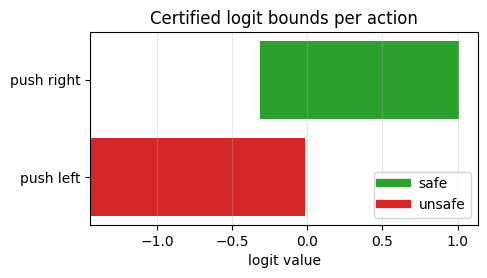

In [31]:
import matplotlib.pyplot as plt
import pandas

logit_bounds_df = pandas.DataFrame(
    {'lower': result.logits_l[idx], 'upper': result.logits_u[idx]},
    index=['push left', 'push right']
)

  
fig, ax = plt.subplots(figsize=(5, 2.5))
action_colours = [
    'tab:green' if is_admissible else 'tab:red'
    for is_admissible in batch_mask[idx]
]
ax.barh(
      logit_bounds_df.index,
      logit_bounds_df["upper"] - logit_bounds_df["lower"],
      left=logit_bounds_df["lower"],
      color=action_colours,
)
ax.set_xlabel("logit value")
ax.set_title("Certified logit bounds per action")
ax.legend(
    handles=[
        plt.Line2D([0], [0], color='tab:green', lw=6, label='safe'),
        plt.Line2D([0], [0], color='tab:red', lw=6, label='unsafe'),
    ],
    loc='lower right',
)
ax.grid(axis="x", alpha=0.3)

## 5. Combining Input-Region and Parameter Uncertainty

`build_bounded_model` also accepts `param_l`/`param_u` bounds on the
network's weights (e.g. a Rashomon-set member from
`interval_utils.compute_rashomon_set`). Input-region uncertainty (`x_l`/`x_u`)
and parameter uncertainty are propagated by the **same single
`bound_forward` call** inside `verify_point` - there's no separate "Rashomon
mode": both flow through one call.


In [32]:
nominal_params = [p.detach().clone() for p in policy.parameters()]
param_radius = 0.01
param_l = [p - param_radius for p in nominal_params]
param_u = [p + param_radius for p in nominal_params]

bounded_model = build_bounded_model(policy, "IBP", param_l=param_l, param_u=param_u)
result = verify_point(
    bounded_model, state, AdmissibleSet(n_classes=2, multi_hot=mask),
    x_l=state_l, x_u=state_u,
)
print(f"certified under input box AND +-{param_radius} weight perturbation: {result.certified.item()}")
print(f"logits_l={result.logits_l.tolist()} logits_u={result.logits_u.tolist()}")


certified under input box AND +-0.01 weight perturbation: True
logits_l=[[0.9574557542800903, -2.880178451538086]] logits_u=[[2.804849624633789, -1.150626540184021]]


In [36]:
mask

tensor([[1., 0.]])

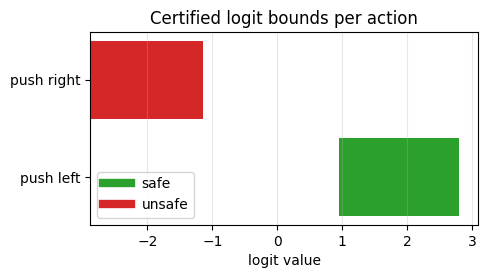

In [38]:
from matplotlib.lines import Line2D

# ensure 1-D arrays for the per-action bounds
logit_l = result.logits_l.detach().cpu().numpy().ravel()
logit_u = result.logits_u.detach().cpu().numpy().ravel()

logit_bounds_df = pandas.DataFrame(
    {'lower': logit_l, 'upper': logit_u},
    index=['push left', 'push right']
)

fig, ax = plt.subplots(figsize=(5, 2.5))
action_colours = [
    'tab:green' if float(v) > 0.5 else 'tab:red'
    for v in mask.squeeze(0).tolist()
]
ax.barh(
      logit_bounds_df.index,
      logit_bounds_df["upper"] - logit_bounds_df["lower"],
      left=logit_bounds_df["lower"],
      color=action_colours,
)
ax.set_xlabel("logit value")
ax.set_title("Certified logit bounds per action")
ax.legend(
    handles=[
        Line2D([0], [0], color='tab:green', lw=6, label='safe'),
        Line2D([0], [0], color='tab:red', lw=6, label='unsafe'),
    ],
    loc='lower left',
)
ax.grid(axis="x", alpha=0.3)

## Notes

- `IBP` is fastest but loosest; `alpha-CROWN` is tighter but more expensive.
- The admissible action set here came from a simple, provably-safe heuristic
  controller, but the same `AdmissibleSet`/`verify_point`/`verify_dataset`
  API works with any state-dependent specification (e.g. valid actions from
  a constrained-RL safety layer, or from a Rashomon-set search).
- `verify_dataset`'s `batch_size` argument can chunk very large certificate
  sets to bound peak memory without changing the result.
